In [1]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import warnings
warnings.filterwarnings('ignore')

with rasterio.open('../data/raw/S2_Season1_BOA_Composite.tif') as src:
    data = src.read().astype(np.float32)

data = np.nan_to_num(data, nan=0.0)
B2,B3,B4,B5,B6,B7,B8,B8A,B11,B12 = [data[i] for i in range(10)]

def safe_div(a, b):
    return np.where((a+b)!=0, (a-b)/(a+b), 0)

NDVI  = safe_div(B8, B4)
EVI   = np.clip(2.5*np.where((B8+6*B4-7.5*B2+1)!=0,(B8-B4)/(B8+6*B4-7.5*B2+1),0),-1,1)
NDWI  = safe_div(B3, B8)
NDRE  = safe_div(B5, B4)
SAVI  = 1.5*safe_div(B8+0.5, B4+0.5)
LAI   = np.clip(3.618*NDVI - 0.118, 0, 8)

print("Indices computed")
print(f"NDVI mean: {NDVI.mean():.4f}")
print(f"EVI  mean: {EVI.mean():.4f}")
print(f"NDWI mean: {NDWI.mean():.4f}")
print(f"LAI  mean: {LAI.mean():.4f}")

Indices computed
NDVI mean: 0.4159
EVI  mean: 0.2789
NDWI mean: -0.4295
LAI  mean: 1.3985


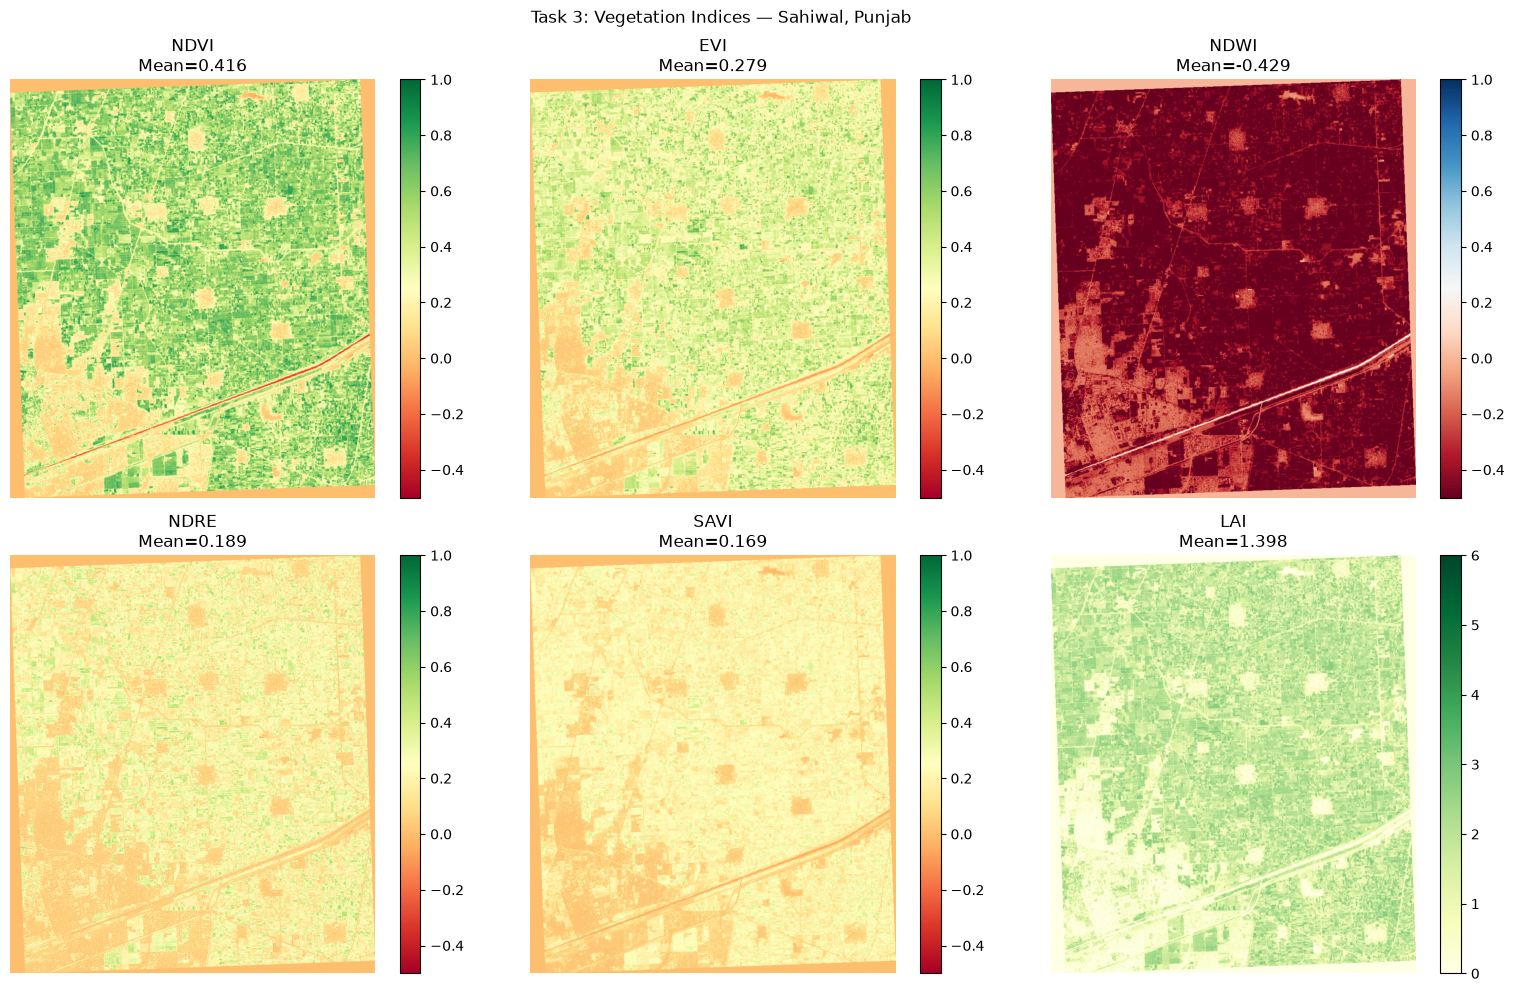

In [2]:
indices = {
    'NDVI': (NDVI, 'RdYlGn'),
    'EVI':  (EVI,  'RdYlGn'),
    'NDWI': (NDWI, 'RdBu'),
    'NDRE': (NDRE, 'RdYlGn'),
    'SAVI': (SAVI, 'RdYlGn'),
    'LAI':  (LAI,  'YlGn'),
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, (index, cmap)) in enumerate(indices.items()):
    im = axes[i].imshow(index, cmap=cmap, vmin=-0.5 if name!='LAI' else 0,
                        vmax=1 if name!='LAI' else 6)
    axes[i].set_title(f'{name}\nMean={np.nanmean(index):.3f}')
    axes[i].axis('off')
    plt.colorbar(im, ax=axes[i], fraction=0.046)

plt.suptitle('Task 3: Vegetation Indices — Sahiwal, Punjab')
plt.tight_layout()
plt.savefig('../data/outputs/task3_notebook_output.png', dpi=150)
plt.show()

In [3]:
print(f"{'Index':<8} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-" * 45)
for name, (index, _) in indices.items():
    print(f"{name:<8} {np.nanmean(index):>8.4f} {np.nanstd(index):>8.4f} "
          f"{np.nanmin(index):>8.4f} {np.nanmax(index):>8.4f}")

Index        Mean      Std      Min      Max
---------------------------------------------
NDVI       0.4159   0.2240  -0.3597   0.8688
EVI        0.2789   0.1577  -0.1127   0.9371
NDWI      -0.4295   0.1798  -0.7624   0.2775
NDRE       0.1887   0.1267  -0.2011   0.6098
SAVI       0.1690   0.0922  -0.0578   0.4510
LAI        1.3985   0.7876   0.0000   3.0254
